## Sistema de agentes musicales con LangGraph + SunnoAPI

El objetivo del siguiente proyecto es crear un sistema de agentes capaz de resolver las consultas del usuario mediante un flujo de agentes que le permita realizar tareas en función de la consulta realizada.

**Instalación de dependencias:**
```
pip install -U langgraph langchain-cohere langchain-core pydantic python-dotenv gradio ipython pillow jupyter ipywidgets

pip install -r requirements.txt
```

**Cada vez que se instale un nuevo paquete:**

```
pip freeze > requirements.txt
```

### Importaciones de paquetes iniciales:

Este es un ejemplo de las dependencias que necesitamos importar para el proyecto, pero todavía falta aclarar todos los paquetes que necesitaremos instalar por lo tanto esto sólo sirve de prueba por el momento.

In [1]:
import os
import time
import random
import requests
import gradio as gr
from typing import Annotated, List, Optional, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
from pydantic import BaseModel, Field
from langchain_cohere import ChatCohere
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import Tool, StructuredTool, tool
from langchain_community.utilities import GoogleSerperAPIWrapper


c:\Users\sabax\OneDrive\Desktop\Trabajo_IA\Trabajos_IA\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Cargamos las variables de entorno desde el archivo .env
load_dotenv(override=True)

False

### Creamos las tools + Agentes

Esto es una prueba y está sujeto a cambio lo más probable es que acabemos utilizando StructuredTool para esto.

Test de creación de tool + agente:

### Agente Investigador

In [3]:
#Definimos el wrapper de búsqueda en Google Serper
serper = GoogleSerperAPIWrapper(serper_api_key=load_dotenv("SERPER_API_KEY"))

ValidationError: 1 validation error for GoogleSerperAPIWrapper
  Value error, Did not find serper_api_key, please add an environment variable `SERPER_API_KEY` which contains it, or pass `serper_api_key` as a named parameter. [type=value_error, input_value={'serper_api_key': False}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error

In [4]:
#Definimos la tool de búsqueda web utilizando el wrapper de Serper
web_search = Tool(
    name="web_search",
    func=serper.run,
    description="Useful for when you need to answer questions about current events or find specific information on the web.",  
)

NameError: name 'serper' is not defined

In [5]:
#Añadimos la tool a la lista de tools del agente
tools = [web_search]    

NameError: name 'web_search' is not defined

### Agente Músico

In [6]:
# Cargamos la clave de la API de Suno desde las variables de entorno para configurar la cabecera de las solicitudes HTTP

SUNO_API_KEY=os.getenv("SUNO_API_KEY")
SUNO_CALLBACK_URL = "https://api.example.com/callback" 
SUNO_BASE_URL="https://api.sunoapi.org/api/v1"
HEADERS = {
    "Authorization": f"Bearer {SUNO_API_KEY}",
    "Content-Type": "application/json"
}

### Esquema de datos

Definimos un esquema de datos con Pydantic que se ajuste al payload que requiere Suno para hacer peticiones a su API

In [7]:
# Esquema de datos 

class MusicCustomSchema(BaseModel):
    prompt: str = Field(description="Letras de la canción o descripción detallada del contenido.")
    style: str = Field(description="Géneron musical o estilo (ej: Classical, Rock, Synthwave).")
    title: str = Field(default="Untitled", description="Título de la canción.")
    instrumental: bool = Field(default=False, description="Si es True, genera solo música sin voz.")
    negativeTags: Optional[str] = Field(default=None, description="Estilos o elementos a evitar.")
    vocalGender: Optional[str] = Field(default=None, description="Género de la voz: 'm' (masculino) o 'f' (femenino).")
    weirdnessConstraint: float = Field(default=0.0, description="Nivel de rareza experimental (0.0 a 1.0).")

### Función auxiliar

Esta función nos permite hacer peticiones GET después de ejecutar la tool de generación de audio para extraer los datos de la canción (en este caso la url)

In [8]:
def _poll_for_audio(task_id: str, max_attempts=30) -> str:
    """Consulta el estado mapeando correctamente sunoData."""
    info_url = f"{SUNO_BASE_URL}/generate/record-info?taskId={task_id}"
    
    for i in range(max_attempts):
        time.sleep(10) 
        try:
            response = requests.get(info_url, headers=HEADERS, timeout=15)
            full_res = response.json()
            data = full_res.get('data', {})
            status = data.get('status')
            
            print(f"   [Polling] Intento {i+1}: Estado {status}")

            if status == 'SUCCESS':
                # Buscamos en 'sunoData' dentro de 'response'
                response_obj = data.get('response', {})
                songs = response_obj.get('sunoData', [])
                
                if songs and len(songs) > 0:
                    # Uso el sourceAudioUrl que es el enlace directo de Suno
                    audio_url = songs[0].get('sourceAudioUrl') or songs[0].get('audioUrl')
                    return f"ESTADO: OPERACIÓN EXITOSA. URL DE DESCARGA: {audio_url}"
                else:
                    return f"ERROR: SUCCESS pero sunoData está vacío. Respuesta: {full_res}"
            
            elif status == 'FAILED':
                return f"ERROR: Fallo en Suno. {data.get('errorMessage')}"
                
        except Exception as e:
            print(f"Error en polling: {e}")
            
    return "ERROR: Tiempo de espera agotado."

### Tools del Agente Musical

In [10]:
# Tool para generación personalizada de música con Suno
@tool(args_schema=MusicCustomSchema)
def suno_generate_custom(
    prompt: str, 
    style: str, 
    title: str = "Untitled", 
    instrumental: bool = False,
    negativeTags: Optional[str] = None,
    vocalGender: Optional[str] = None,
    weirdnessConstraint: float = 0.0
) -> str:
    """Genera música personalizada usando el modelo V4_5ALL de Suno."""
    url = f"{SUNO_BASE_URL}/generate"
    
    payload = {
        "customMode": True,
        "instrumental": instrumental,
        "model": "V4_5ALL",
        "callBackUrl": SUNO_CALLBACK_URL, 
        "prompt": prompt,
        "style": style,
        "title": title,
        "styleWeight": 0.65,
        "weirdnessConstraint": weirdnessConstraint,
        "audioWeight": 0.65
    }
    
    if negativeTags:
        payload["negativeTags"] = negativeTags

    if vocalGender:
        payload["vocalGender"] = vocalGender


    try:
        print(f"DEBUG: Enviando a {url}...")
        response = requests.post(url, json=payload, headers=HEADERS, timeout=30)
        res_json = response.json()
        
        # Validación de la respuesta
        if res_json.get('code') != 200:
            msg = res_json.get('msg', 'Error desconocido')
            print(f"❌ ERROR API ({res_json.get('code')}): {msg}")
            return f"Error de Suno: {msg}"

        # Si llegamos aquí, data ya no debería ser None
        data = res_json.get('data')
        task_id = data.get('taskId')
        
        print(f"✅ Tarea aceptada. ID: {task_id}. Iniciando polling...")
        return _poll_for_audio(task_id)

    except Exception as e:
        print(f"❌ ERROR CRÍTICO: {str(e)}")
        return f"Error al llamar a Suno: {str(e)}"
    
# Esta tool hay que testearla todavía
@tool
def suno_extend_audio(audio_id: str, prompt: str) -> str:
    """Extiende una canción existente dado su audio_id."""
    url = f"{SUNO_BASE_URL}/generate/continue"
    payload = {"audioId": audio_id, "prompt": prompt}
    try:
        response = requests.post(url, json=payload, headers=HEADERS)
        task_id = response.json().get('data', {}).get('taskId')
        return _poll_for_audio(task_id)
    except Exception as e:
        return f"Error al extender: {str(e)}"

In [11]:
# 1. Definición del Estado del Agente
class AgentState(TypedDict):
    # Annotated con add_messages permite que los nuevos mensajes 
    # se concatenen al historial en lugar de sobrescribirlo.
    messages: Annotated[List[BaseMessage], add_messages]

# Nodo del Agente Musical
def musician_node(state: AgentState):
    """
    Nodo Musician Unificado:
    Combina la ingeniería de prompts detallada con la configuración
    nativa de Cohere para garantizar la entrega de la URL.
    """

    # Instrucciones elaboradas (Preamble)
    preamble = (
        "Eres el experto en producción de audio y composición AI (nodo 'mus.'). "
        "Tu responsabilidad principal es transformar las peticiones creativas del usuario "
        "en parámetros técnicos precisos para la API de Suno utilizando el modelo 'V4_5ALL'.\n\n"
        
        "### TAREAS ESPECÍFICAS:\n"
        "1. TRADUCCIÓN DE ESTILO: Mapea descripciones sensoriales a etiquetas de género en el campo 'style' "
        "(ej: 'música para estudiar' -> 'lo-fi, chill, minimalist piano').\n"
        "2. CONTROL DE RAREZA: Si el usuario menciona términos como 'experimental', 'extraño', 'vanguardista' "
        "o 'nunca antes escuchado', incrementa el valor de 'weirdnessConstraint' (rango 0.0 a 1.0).\n"
        "3. FILTRADO NEGATIVO: Identifica elementos no deseados (ej: 'sin batería', 'no guitarras') y "
        "colócalos exclusivamente en el campo 'negativeTags' sin usar palabras de negación.\n"
        "4. IDENTIDAD VOCAL: Si detectas que el usuario prefiere una voz masculina o femenina, "
        "asigna 'm' o 'f' al campo 'vocalGender'. Si pide instrumental, activa 'instrumental=True'.\n\n"
        
        "### REGLAS DE OPERACIÓN CRÍTICAS:\n"
        "- Si la herramienta devuelve 'ESTADO: OPERACIÓN EXITOSA', extrae la URL y dásela al usuario.\n"
        "- NUNCA digas que hubo un error o que lo sientes si recibes una URL de descarga en el historial.\n"
        "- No inventes la URL. Debes esperar a que la herramienta confirme el estado 'SUCCESS' mediante el polling.\n"
        "- Tu respuesta final DEBE incluir la URL del audio y un breve resumen técnico de la producción realizada.\n"
        "- IMPORTANTE: Ignora los múltiples mensajes de estado intermedio (PENDING, TEXT_SUCCESS) del historial; "
        "céntrate únicamente en el mensaje final de la herramienta que contiene la URL."
    )

    # Configuración del LLM
    llm = ChatCohere(
        model="command-a-03-2025", 
        temperature=0,
        preamble=preamble
    )
    
    # Vinculación de herramientas
    llm_with_tools = llm.bind_tools([suno_generate_custom, suno_extend_audio])

    # Invocación pasando el historial completo del estado
    response = llm_with_tools.invoke(state["messages"])
    
    return {"messages": [response]}

In [12]:
# Construcción del grafo
workflow = StateGraph(AgentState)
workflow.add_node("agente musical", musician_node)
workflow.add_node("tools", ToolNode([suno_generate_custom, suno_extend_audio]))

workflow.set_entry_point("agente musical")
workflow.add_conditional_edges("agente musical", tools_condition, ["tools", END])
workflow.add_edge("tools", "agente musical")

music_agent = workflow.compile()

### Test agente musical

In [13]:
def run_test():
    test_query = (
        "Crea una canción de Techno melódico llamada 'Código Infinito'. "
        "Quiero que suene MUY experimental y vanguardista, pero por favor, "
        "que NO tenga sonidos de percusión agresivos ni voces. "
        "La voz debe ser femenina si decides incluir algún susurro."
    )
    
    # Inicializamos el estado con la pregunta del usuario
    inputs = {"messages": [HumanMessage(content=test_query)]}

    print(f"🔔 Iniciando Test del Agente Musical ('mus.')...\n")
    print(f"ENTRADA DEL USUARIO:\n'{test_query}'\n")
    print("-" * 50)

    last_msg = None # Variable para capturar la respuesta final

    # Ejecutamos el grafo
    for chunk in music_agent.stream(inputs, stream_mode="updates"):
        for node, values in chunk.items():
            print(f"📍 Nodo actual: {node}")
            
            # Si el nodo contiene mensajes, actualizamos last_msg
            if "messages" in values:
                last_msg = values["messages"][-1]
                
                # Opcional: Si el mensaje es una llamada a herramienta, lo indicamos
                if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                    for tool in last_msg.tool_calls:
                        print(f"🛠️ El agente está llamando a: {tool['name']}")

    # --- AQUÍ ESTÁ EL BLOQUE CLAVE ---
    if last_msg:
        print("\n" + "="*40)
        print("🤖 RESPUESTA FINAL DEL AGENTE:")
        print(last_msg.content)
        print("="*40)
    else:
        print("\n❌ No se recibió ninguna respuesta final del agente.")

if __name__ == "__main__":
    run_test()

🔔 Iniciando Test del Agente Musical ('mus.')...

ENTRADA DEL USUARIO:
'Crea una canción de Techno melódico llamada 'Código Infinito'. Quiero que suene MUY experimental y vanguardista, pero por favor, que NO tenga sonidos de percusión agresivos ni voces. La voz debe ser femenina si decides incluir algún susurro.'

--------------------------------------------------


UnauthorizedError: headers: {'cache-control': 'no-cache, no-store, no-transform, must-revalidate, private, max-age=0', 'content-encoding': 'gzip', 'content-type': 'application/json', 'expires': 'Thu, 01 Jan 1970 00:00:00 GMT', 'pragma': 'no-cache', 'vary': 'Origin,Accept-Encoding', 'x-accel-expires': '0', 'date': 'Sun, 11 Jan 2026 18:20:16 GMT', 'x-envoy-upstream-service-time': '1', 'server': 'envoy', 'via': '1.1 google', 'alt-svc': 'h3=":443"; ma=2592000,h3-29=":443"; ma=2592000', 'transfer-encoding': 'chunked'}, status_code: 401, body: {'id': 'ae146d40-ede5-40ba-9b1a-39c6d6a33bb1', 'message': 'no api key supplied'}

### Agente Editor

In [19]:
# --- IMPORTS FROM EDITOR NODE ---
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders
from fpdf import FPDF
from typing import TypedDict, List, Dict, Any, Optional
import os
from langchain_core.tools import tool

# --- STATE DEFINITION FOR EDITOR ---
class State(TypedDict):
    concerts: List[Dict[str, Any]]
    suno_audio_url: str
    formato_entrega: str
    pdf_path: str
    user_email: Optional[str]
    mp3_path: Optional[str]
    messages: Annotated[List[BaseMessage], add_messages]

### Tools


In [ ]:
# --- PDF GENERATION ---
def generate_pdf(concerts: List[Dict[str, Any]], suno_audio_url: str) -> str:
    """
    Genera un PDF con la lista de conciertos y el enlace a Suno.
    Retorna la ruta absoluta del archivo generado.
    """
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=12)

    # Título
    pdf.set_font("Arial", style="B", size=16)
    pdf.cell(200, 10, txt="Resumen de Conciertos & Música", ln=True, align='C')
    pdf.ln(10)

    # Tabla de Conciertos
    pdf.set_font("Arial", style="B", size=12)
    # Encabezados
    pdf.cell(40, 10, "Fecha", 1)
    pdf.cell(60, 10, "Ciudad", 1)
    pdf.cell(30, 10, "Precio", 1)
    pdf.cell(60, 10, "Link", 1)
    pdf.ln()

    pdf.set_font("Arial", size=11)
    for concert in concerts:
        # Aseguramos que los datos sean strings
        fecha = str(concert.get("fecha", "N/A"))
        ciudad = str(concert.get("ciudad", "N/A"))
        precio = str(concert.get("precio", "N/A"))
        link = str(concert.get("link", "N/A"))

        pdf.cell(40, 10, fecha, 1)
        pdf.cell(60, 10, ciudad, 1)
        pdf.cell(30, 10, precio, 1)
        # Podríamos hacer un link clicable si FPDF2 lo permite facilemente con cell, 
        # pero por simplicidad mostramos el texto acortado
        pdf.cell(60, 10, link[:25]+"..." if len(link)>25 else link, 1)
        pdf.ln()

    pdf.ln(20)

    # Audio Suno
    pdf.set_font("Arial", style="B", size=12)
    pdf.cell(200, 10, txt="Tu Canción Personalizada (Suno)", ln=True, align='L')
    pdf.set_font("Arial", size=12)
    pdf.write(5, f"Escucha tu canción aquí: {suno_audio_url}", link=suno_audio_url)
    pdf.ln(10)
    
    # Podríamos añadir una imagen QR aquí si tuvieramos la librería qrcode, 
    # pero el requerimiento dice 'o enlace clicable'.

    output_filename = "conciertos_suno.pdf"
    # Guardar en el directorio actual
    pdf.output(output_filename)
    return os.path.abspath(output_filename)

@tool
def generate_pdf_tool(concerts: List[Dict[str, Any]], suno_audio_url: str) -> str:
    """Genera el PDF con conciertos y link de audio."""
    return generate_pdf(concerts, suno_audio_url)

# --- EMAIL TOOL ---
@tool
def send_email_tool(pdf_path: str, receiver_email: str, mp3_path: Optional[str] = None):
    """Envía el PDF generado y opcionalmente un MP3 por correo electrónico."""
    sender_email = os.getenv("EMAIL_SENDER")
    sender_password = os.getenv("EMAIL_PASSWORD")
    
    if not sender_email or not sender_password:
        print("Advertencia: No se han configurado EMAIL_SENDER o EMAIL_PASSWORD. No se envió el correo.")
        return "Error: Credenciales faltantes"

    msg = MIMEMultipart()
    msg['From'] = sender_email
    msg['To'] = receiver_email
    msg['Subject'] = "Tu Resumen de Conciertos y Música"

    body = "Adjunto encontrarás el PDF con la información de los conciertos y tu canción de Suno."
    msg.attach(MIMEText(body, 'plain'))

    # Adjuntar PDF
    try:
        filename = os.path.basename(pdf_path)
        with open(pdf_path, "rb") as attachment:
            part = MIMEBase("application", "octet-stream")
            part.set_payload(attachment.read())
        
        encoders.encode_base64(part)
        part.add_header(
            "Content-Disposition",
            f"attachment; filename= {filename}",
        )
        msg.attach(part)

        # Adjuntar MP3 si existe
        if mp3_path and os.path.exists(mp3_path):
            try:
                mp3_filename = os.path.basename(mp3_path)
                with open(mp3_path, "rb") as attachment:
                    part = MIMEBase("audio", "mpeg")
                    part.set_payload(attachment.read())
                
                encoders.encode_base64(part)
                part.add_header(
                    "Content-Disposition",
                    f"attachment; filename= {mp3_filename}",
                )
                msg.attach(part)
            except Exception as e:
                print(f"Error adjuntando MP3: {e}")

        server = smtplib.SMTP('smtp.gmail.com', 587)
        server.starttls()
        server.login(sender_email, sender_password)
        server.send_message(msg)
        server.quit()
        return "Correo enviado con éxito"
    except Exception as e:
        print(f"Error enviando correo: {e}")
        return f"Error enviando correo: {e}"


### Nodo Editor

In [ ]:
# --- EDITOR NODE LOGIC ---
def editor_node(state: State) -> State:
    """
    Nodo Editor: Genera PDF y gestiona el envío.
    """
    print("--- NODO EDITOR ---")
    
    # 1. Extraer datos
    concerts = state.get("concerts", [])
    suno_url = state.get("suno_audio_url", "")
    formato = state.get("formato_entrega", "local")
    email = state.get("user_email", "")
    mp3_path = state.get("mp3_path", None)

    # 2. Generar PDF
    # Llamamos a la lógica directamente o invocamos la tool si fuera un agente LLM.
    # Como es un nodo determinista, llamamos directo a la función subyacente o a la tool.
    pdf_file = generate_pdf(concerts, suno_url)
    
    # Actualizamos el path en el estado (temporalmente antes de retornar)
    state["pdf_path"] = pdf_file

    # 3. Evaluar condición de envío
    if formato == "email":
        if email:
            print(f"Enviando correo a {email}...")
            # Mock de envío o envío real
            result = send_email_tool.invoke({"pdf_path": pdf_file, "receiver_email": email, "mp3_path": mp3_path})
            print(f"Resultado envío: {result}")
        else:
            print("Se solicitó email pero no se proporcionó dirección. Guardado local.")
            print(f"Archivo guardado en local: {pdf_file}")
    else:
        print(f"Archivo guardado en local: {pdf_file}")

    return state


### Visualizar grafo

Visualizando el Grafo Completo (Músico -> Editor)...


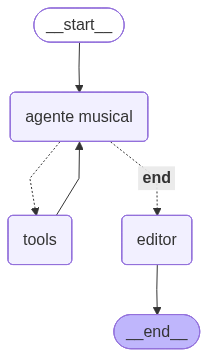

In [21]:
# --- VISUALIZACIÓN DEL GRAFO COMPLETO ---
try:
    from langgraph.graph import StateGraph, START, END
    from IPython.display import Image, display

    # Definimos un Estado Unificado que combine todos los campos necesarios
    class UnifiedState(TypedDict):
        messages: Annotated[List[BaseMessage], add_messages]
        concerts: List[Dict[str, Any]]
        suno_audio_url: str
        formato_entrega: str
        pdf_path: str
        user_email: Optional[str]
        mp3_path: Optional[str]

    # Construimos el workflow completo
    workflow_completo = StateGraph(UnifiedState)
    
    # Agregamos los nodos
    # Nota: Asegúrate de que las funciones de nodo (musician_node, editor_node) acepten este estado.
    workflow_completo.add_node("agente musical", musician_node)
    workflow_completo.add_node("tools", ToolNode([suno_generate_custom, suno_extend_audio]))
    workflow_completo.add_node("editor", editor_node)

    # Definimos el flujo
    workflow_completo.set_entry_point("agente musical")
    
    # Del músico a tools o al editor (en lugar de END)
    workflow_completo.add_conditional_edges(
        "agente musical", 
        tools_condition, 
        {"tools": "tools", END: "editor"}
    )
    
    workflow_completo.add_edge("tools", "agente musical")
    workflow_completo.add_edge("editor", END)

    # Compilamos
    app_completa = workflow_completo.compile()

    print("Visualizando el Grafo Completo (Músico -> Editor)...")
    try:
        display(Image(app_completa.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Error al generar imagen PNG: {e}")
        print("Diagrama ASCII:")
        print(app_completa.get_graph().draw_ascii())

except Exception as e:
    print(f"Error al construir/visualizar el grafo completo: {e}")

